In [1]:
# =========================================================
# OUTLIERS ANALYSIS - KAGGLE DATASET
# Dataset: House Prices (Ames Housing)
# https://www.kaggle.com/c/house-prices-advanced-regression-techniques
# =========================================================

In [2]:
# Instala las librerías (ejecuta una vez en el notebook)
%pip install -q pandas numpy scipy seaborn matplotlib

# LIBRERÍAS
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sns.set_theme(style="whitegrid")


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [5]:
# CARGA DE DATOS
# Asegúrate de que 'train.csv' esté en el mismo directorio
df = pd.read_csv('train.csv')

In [6]:
# EXPLORACIÓN INICIAL
print("Dimensiones:", df.shape)
display(df.head())

# Estadísticas básicas
display(df.describe())

Dimensiones: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


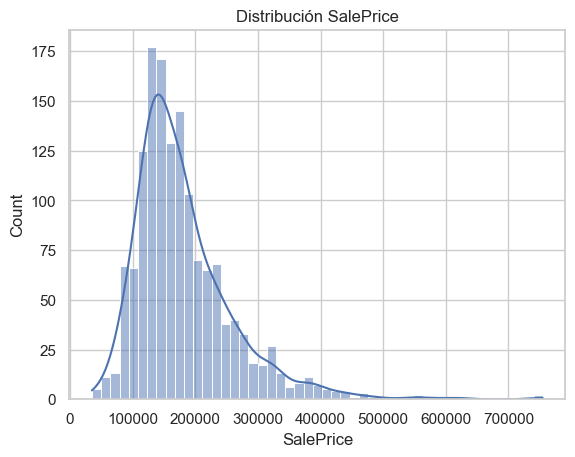

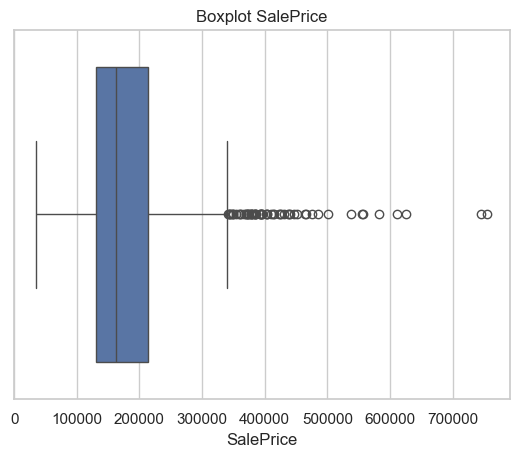

Skewness SalePrice: 1.8828757597682129
Outliers en SalePrice: 61


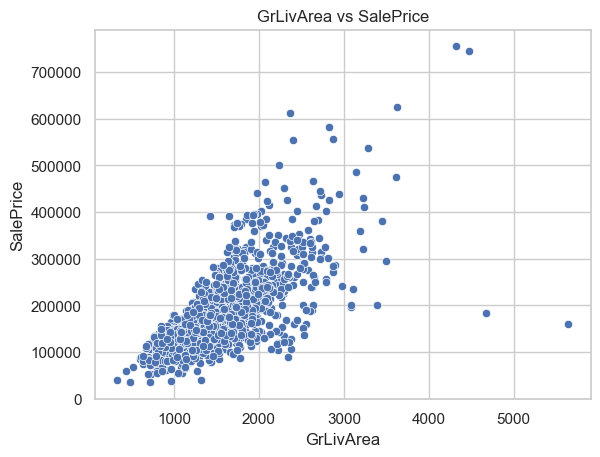

Outliers GrLivArea: 4


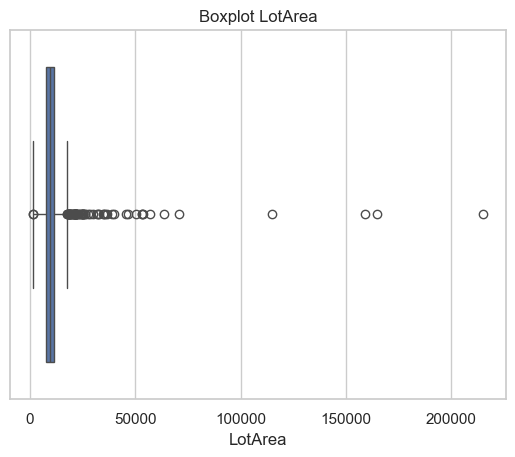

Outliers LotArea (Z>3): 13


In [7]:
# =========================================================
# DETECCIÓN DE OUTLIERS
# =========================================================

# ---------------------------
# Variable: SalePrice
# ---------------------------
plt.figure()
sns.histplot(df['SalePrice'], kde=True)
plt.title("Distribución SalePrice")
plt.show()

plt.figure()
sns.boxplot(x=df['SalePrice'])
plt.title("Boxplot SalePrice")
plt.show()

# Skewness
print("Skewness SalePrice:", df['SalePrice'].skew())

# IQR
Q1 = df['SalePrice'].quantile(0.25)
Q3 = df['SalePrice'].quantile(0.75)
IQR = Q3 - Q1

outliers_saleprice = df[
    (df['SalePrice'] < (Q1 - 1.5 * IQR)) | 
    (df['SalePrice'] > (Q3 + 1.5 * IQR))
]

print("Outliers en SalePrice:", outliers_saleprice.shape[0])

# ---------------------------
# Variable: GrLivArea
# ---------------------------
plt.figure()
sns.scatterplot(x=df['GrLivArea'], y=df['SalePrice'])
plt.title("GrLivArea vs SalePrice")
plt.show()

# Outliers claros
outliers_grliv = df[df['GrLivArea'] > 4000]
print("Outliers GrLivArea:", outliers_grliv.shape[0])

# ---------------------------
# Variable: LotArea
# ---------------------------
plt.figure()
sns.boxplot(x=df['LotArea'])
plt.title("Boxplot LotArea")
plt.show()

# Z-score (evitando NaN)
lotarea_clean = df['LotArea'].dropna()
z_scores = np.abs(stats.zscore(lotarea_clean))

outliers_lotarea = df.loc[lotarea_clean.index[z_scores > 3]]
print("Outliers LotArea (Z>3):", outliers_lotarea.shape[0])

In [8]:
# =========================================================
# ⚠️ TRATAMIENTO DE OUTLIERS
# =========================================================

# Eliminar outliers inconsistentes (GrLivArea)
df_clean = df[df['GrLivArea'] < 4000].copy()

print("Datos originales:", df.shape)
print("Datos limpios:", df_clean.shape)

Datos originales: (1460, 81)
Datos limpios: (1456, 81)


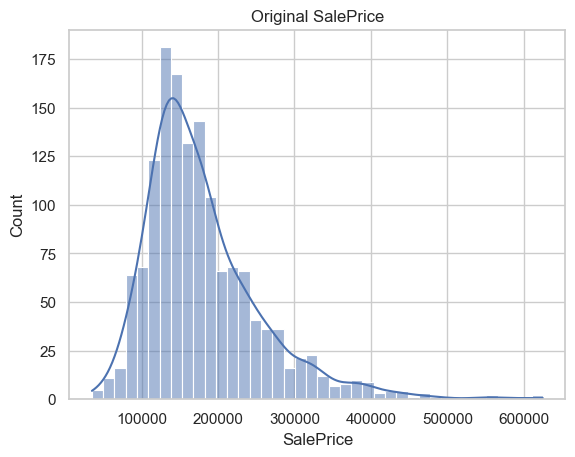

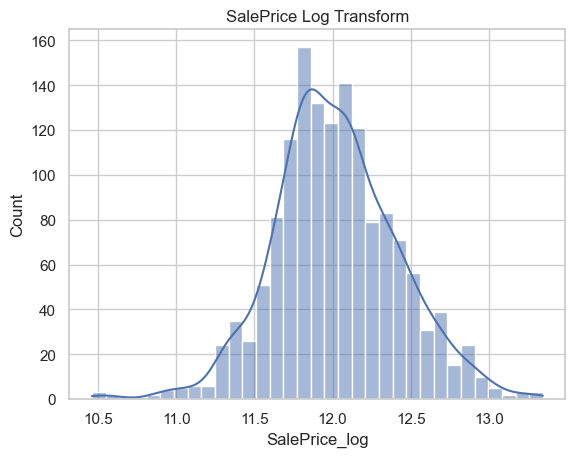

Skewness original: 1.5659592925562151
Skewness transformado: 0.06546006911025826


In [9]:
# =========================================================
# TRANSFORMACIONES
# =========================================================

# Transformación logarítmica (sin warning)
df_clean.loc[:, 'SalePrice_log'] = np.log1p(df_clean['SalePrice'])

# Comparación
plt.figure()
sns.histplot(df_clean['SalePrice'], kde=True)
plt.title("Original SalePrice")
plt.show()

plt.figure()
sns.histplot(df_clean['SalePrice_log'], kde=True)
plt.title("SalePrice Log Transform")
plt.show()

print("Skewness original:", df_clean['SalePrice'].skew())
print("Skewness transformado:", df_clean['SalePrice_log'].skew())

In [10]:
# =========================================================
# CONCLUSIONES
# =========================================================

print("""
CONCLUSIONES:

1. Sí existen outliers en el dataset.
2. Variables afectadas:
- SalePrice (sesgo positivo)
- GrLivArea (valores extremos >4000)
- LotArea (alta dispersión)

3. Acciones tomadas:
- Eliminación de outliers inconsistentes en GrLivArea
- Transformación logarítmica en SalePrice

4. Resultados:
- Reducción del skewness
- Mejor distribución para modelado
""")


CONCLUSIONES:

1. Sí existen outliers en el dataset.
2. Variables afectadas:
- SalePrice (sesgo positivo)
- GrLivArea (valores extremos >4000)
- LotArea (alta dispersión)

3. Acciones tomadas:
- Eliminación de outliers inconsistentes en GrLivArea
- Transformación logarítmica en SalePrice

4. Resultados:
- Reducción del skewness
- Mejor distribución para modelado



In [11]:
pip install mlxtend


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



     ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
     -- ------------------------------------- 0.1/1.4 MB 2.3 MB/s eta 0:00:01
     ----- ---------------------------------- 0.2/1.4 MB 2.4 MB/s eta 0:00:01
     -------- ------------------------------- 0.3/1.4 MB 2.0 MB/s eta 0:00:01
     ---------- ----------------------------- 0.4/1.4 MB 1.9 MB/s eta 0:00:01
     ------------ --------------------------- 0.4/1.4 MB 1.8 MB/s eta 0:00:01
     ------------- -------------------------- 0.5/1.4 MB 1.7 MB/s eta 0:00:01
     ------------- -------------------------- 0.5/1.4 MB 1.7 MB/s eta 0:00:01
     ------------- -------------------------- 0.5/1.4 MB 1.7 MB/s eta 0:00:01
     -------------- ------------------------- 0.5/1.4 MB 1.2 MB/s eta 0:00:01
     ---------------- ----------------------- 0.6/1.4 MB 1.2 MB/s eta 0:00:01
     ----------------- ---------------------- 0.6/1.4 MB 1.3 MB/s eta 0:00:01
     ------------------ --------------------- 0.6/1.4 MB 1.2 MB/s eta 

In [12]:
# =========================================================
# 📊 ASSOCIATION RULES - AMES HOUSING
# =========================================================

import pandas as pd
import numpy as np

from mlxtend.frequent_patterns import apriori, association_rules

# 📥 Cargar datos
df = pd.read_csv('train.csv')

In [13]:
# =========================================================
# PREPROCESAMIENTO
# =========================================================

# Seleccionar variables relevantes
df_ar = df[['OverallQual', 'GrLivArea', 'GarageCars', 'Neighborhood', 'SalePrice']].copy()

# Discretizar variables numéricas (convertir a categorías)
df_ar['Quality'] = pd.cut(df_ar['OverallQual'], bins=[0,5,7,10], labels=['Low','Medium','High'])
df_ar['Area'] = pd.cut(df_ar['GrLivArea'], bins=3, labels=['Small','Medium','Large'])
df_ar['Garage'] = pd.cut(df_ar['GarageCars'], bins=[-1,1,2,4], labels=['Small','Medium','Large'])
df_ar['Price'] = pd.qcut(df_ar['SalePrice'], q=3, labels=['Low','Medium','High'])

# Seleccionar solo categóricas
df_ar = df_ar[['Quality','Area','Garage','Neighborhood','Price']]

# One-hot encoding
df_encoded = pd.get_dummies(df_ar)

In [14]:
# =========================================================
# APLICAR APRIORI
# =========================================================

frequent_items = apriori(df_encoded, min_support=0.1, use_colnames=True)

# Reglas de asociación
rules = association_rules(frequent_items, metric="lift", min_threshold=1)

# Ordenar por confianza
rules = rules.sort_values(by='confidence', ascending=False)

# Mostrar resultados
rules[['antecedents','consequents','support','confidence','lift']].head(10)

,antecedents,consequents,support,confidence,lift
95,"(Quality_Low, Garage_Small, Price_Low)",(Area_Small),0.178767,0.992395,1.121438
109,"(Price_Medium, Quality_Medium, Garage_Medium)",(Area_Small),0.185616,0.985455,1.113594
60,"(Price_Medium, Quality_Medium)",(Area_Small),0.221918,0.984802,1.112857
34,"(Quality_Low, Garage_Small)",(Area_Small),0.215753,0.984375,1.112374
43,"(Quality_Low, Price_Low)",(Area_Small),0.256164,0.984211,1.112188
81,"(Garage_Small, Price_Low)",(Area_Small),0.225342,0.982090,1.109792
23,(Price_Low),(Area_Small),0.325342,0.975359,1.102186
0,(Quality_Low),(Area_Small),0.356849,0.968401,1.094324
87,"(Price_Medium, Garage_Medium)",(Area_Small),0.248630,0.968000,1.093870
24,(Price_Medium),(Area_Small),0.324658,0.967347,1.093132


In [15]:
print("Número de reglas encontradas:", len(rules))

Número de reglas encontradas: 134
